<a href="https://colab.research.google.com/github/Pankaj-70/dl_practicals/blob/main/grePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd

In [49]:
df = pd.read_csv('/content/sample_data/Admission_Predict.csv')

In [50]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [51]:
df.drop(columns=['Serial No.'], inplace=True)

In [52]:
X = df.drop(columns = ['Chance of Admit '])
y = df['Chance of Admit ']

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [54]:
from sklearn.preprocessing import MinMaxScaler
mmx = MinMaxScaler()
X_train_scaled = mmx.fit_transform(X_train)
X_test_scaled = mmx.fit_transform(X_test)

In [55]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [56]:
df.sample(5)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
244,314,107,2,2.5,4.0,8.56,0,0.63
318,324,111,3,2.5,2.0,8.80,1,0.79
371,324,110,3,3.5,3.0,9.22,1,0.89
97,331,120,3,4.0,4.0,8.96,1,0.86
99,323,113,3,4.0,4.0,8.88,1,0.79


In [57]:
model = Sequential([
    Input(shape=(7, )),
    Dense(7, activation='relu'),
    Dense(1, activation='linear'),
])

In [58]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.compile(loss='mean_squared_error', optimizer='Adam', metrics = ['accuracy'])

In [60]:
history = model.fit(X_train_scaled, y_train, epochs = 100, validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.0000e+00 - loss: 0.9791 - val_accuracy: 0.0000e+00 - val_loss: 1.0143
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0000e+00 - loss: 0.8778 - val_accuracy: 0.0000e+00 - val_loss: 0.9146
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0000e+00 - loss: 0.7936 - val_accuracy: 0.0000e+00 - val_loss: 0.8293
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0000e+00 - loss: 0.7201 - val_accuracy: 0.0000e+00 - val_loss: 0.7578
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0000e+00 - loss: 0.6600 - val_accuracy: 0.0000e+00 - val_loss: 0.6990
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0000e+00 - loss: 0.6102 - val_accuracy: 0.0000e+00 - val_loss: 0.6523
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0000e+00 - loss: 0.5709 - val_accuracy: 0.0000e+00 - val_loss: 0.6150
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 

In [61]:
y_pred = model.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


In [62]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.5451454254879557

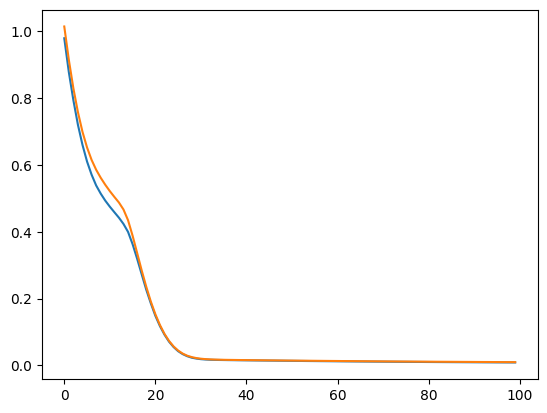

In [63]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

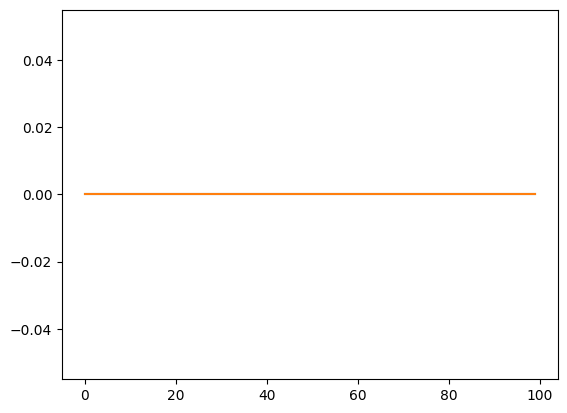

In [64]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()